In [12]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

In [2]:
# Constants and config
REPO_ROOT = Path("../")
DATA_PATH = REPO_ROOT / "data" / "simulated_users.csv"

RANDOM_SEED = 42
CV_FOLDS = 5

ABUSE_TIERS = {"high_confidence_abuse": 1, "suspected": 1, "clean": 0}

COLOR_LOGIT = "#3498db"
COLOR_GBT = "#e74c3c"
FIGSIZE = (12, 5)

# ML-Based Abuse Detection: Behavioral Fingerprinting

This notebook builds on the rule-based analysis by training learned models over the full behavioral feature space.

The progression:
1. **Logistic regression** — interpretable baseline, shows which features have linear discriminative power
2. **Gradient boosting (HistGradientBoosting)** — captures non-linear interactions between signals
3. **SHAP analysis** — explains what the boosting model actually learned

Both models are evaluated with precision-recall curves (not accuracy — the class imbalance makes accuracy misleading).

**This is a progression from, not a replacement for, rule-based detection.** In production, rules provide fast, interpretable flagging; the ML model handles the ambiguous middle tier.

## 1. Load Data and Feature Engineering

In [3]:
df = pd.read_csv(DATA_PATH)
df["is_abuse"] = df["abuse_confidence"].map(ABUSE_TIERS)

print(f"Dataset: {len(df):,} accounts")
print(f"Abuse rate: {df['is_abuse'].mean():.1%}")
print(f"\nLabel distribution:")
print(df["abuse_confidence"].value_counts().to_string())

Dataset: 5,000 accounts
Abuse rate: 21.5%

Label distribution:
abuse_confidence
clean                    3925
high_confidence_abuse     556
suspected                 519


In [4]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Engineer behavioral and device features for abuse detection models.

    Args:
        df: Raw account DataFrame.

    Returns:
        DataFrame with engineered features only (no raw identifiers).
    """
    features = pd.DataFrame(index=df.index)

    # --- Behavioral features ---
    features["hours_to_exhaust"] = df["hours_to_quota_exhaustion"].fillna(9999)
    features["quota_exhausted"] = df["quota_exhausted"].astype(int)
    features["return_after_exhaust"] = df["return_after_exhaustion"].astype(int)
    features["days_active"] = df["days_active"]
    features["total_sessions"] = df["total_sessions"]
    features["avg_session_duration_mins"] = df["avg_session_duration_mins"]
    features["api_calls_count"] = df["api_calls_count"]
    features["features_used"] = df["features_used"]
    features["days_since_last_active"] = df["days_since_last_active"]

    # --- Derived behavioral ratios ---
    features["api_calls_per_day"] = df["api_calls_count"] / df["days_active"].clip(lower=1)
    features["sessions_per_day"] = df["total_sessions"] / df["days_active"].clip(lower=1)
    # "Burst" score: high API with fast exhaustion
    features["burst_score"] = features["api_calls_per_day"] / (
        features["hours_to_exhaust"].clip(lower=1) / 24
    )

    # --- Device / account features ---
    features["cluster_size"] = df["accounts_in_cluster"]
    features["is_disposable_email"] = (df["email_domain_type"] == "disposable").astype(int)
    features["is_free_webmail"] = (df["email_domain_type"] == "free_webmail").astype(int)
    features["is_vpn_datacenter"] = df["asn_type"].isin(["vpn", "datacenter", "tor"]).astype(int)
    features["rtt_ms"] = df["round_trip_time_ms"].fillna(df["round_trip_time_ms"].median())
    features["is_mobile"] = (df["device_type"] == "Mobile").astype(int)

    return features


X = engineer_features(df)
y = df["is_abuse"]

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"Features: {list(X.columns)}")

Feature matrix: 5,000 rows x 18 features
Features: ['hours_to_exhaust', 'quota_exhausted', 'return_after_exhaust', 'days_active', 'total_sessions', 'avg_session_duration_mins', 'api_calls_count', 'features_used', 'days_since_last_active', 'api_calls_per_day', 'sessions_per_day', 'burst_score', 'cluster_size', 'is_disposable_email', 'is_free_webmail', 'is_vpn_datacenter', 'rtt_ms', 'is_mobile']


## 2. Logistic Regression Baseline

In [5]:
logit_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=500,
        random_state=RANDOM_SEED,
    )),
])

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

logit_proba = cross_val_predict(
    logit_pipe, X, y, cv=cv, method="predict_proba"
)[:, 1]

logit_ap = average_precision_score(y, logit_proba)
logit_auc = roc_auc_score(y, logit_proba)

print(f"Logistic Regression ({CV_FOLDS}-fold CV):")
print(f"  Average Precision (AP): {logit_ap:.3f}")
print(f"  ROC-AUC: {logit_auc:.3f}")

# Fit on full data for coefficient inspection
logit_pipe.fit(X, y)
logit_coefs = pd.Series(
    logit_pipe.named_steps["clf"].coef_[0],
    index=X.columns,
).sort_values(key=abs, ascending=False)

print("\nTop feature coefficients:")
print(logit_coefs.head(10).to_string())

Logistic Regression (5-fold CV):
  Average Precision (AP): 0.900
  ROC-AUC: 0.935

Top feature coefficients:
hours_to_exhaust            -3.154099
quota_exhausted             -2.731795
days_active                 -0.955744
sessions_per_day            -0.708404
features_used               -0.657453
api_calls_count              0.570657
avg_session_duration_mins   -0.428753
cluster_size                 0.408931
is_disposable_email          0.376595
return_after_exhaust        -0.325955


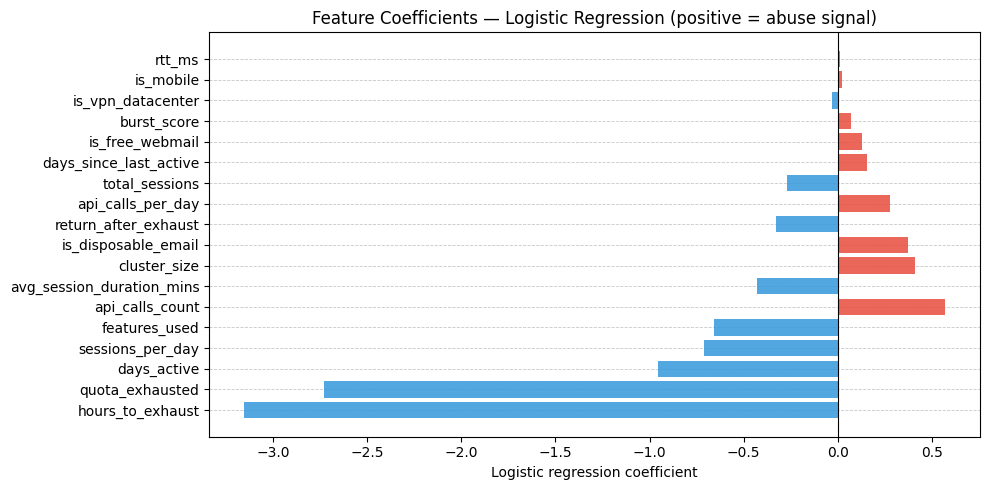

Figure: Logistic regression coefficients. Positive values indicate features associated with abuse; negative values with clean accounts. Fast quota exhaustion, disposable email, and high burst score are the strongest positive predictors. High feature breadth and longer session duration are associated with legitimate use.


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLOR_GBT if c > 0 else COLOR_LOGIT for c in logit_coefs.values]
ax.barh(logit_coefs.index, logit_coefs.values, color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Logistic regression coefficient")
ax.set_title("Feature Coefficients — Logistic Regression (positive = abuse signal)")
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print("Figure: Logistic regression coefficients. Positive values indicate features associated with abuse; negative values with clean accounts. Fast quota exhaustion, disposable email, and high burst score are the strongest positive predictors. High feature breadth and longer session duration are associated with legitimate use.")

## 3. Gradient Boosting (HistGradientBoostingClassifier)

scikit-learn's `HistGradientBoostingClassifier` uses histogram-based gradient boosting — the same algorithmic family as XGBoost and LightGBM, with no external system dependencies.

In [7]:
gbt_model = HistGradientBoostingClassifier(
    max_iter=300,
    max_depth=4,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=RANDOM_SEED,
)

gbt_proba = cross_val_predict(
    gbt_model, X, y, cv=cv, method="predict_proba"
)[:, 1]

gbt_ap = average_precision_score(y, gbt_proba)
gbt_auc = roc_auc_score(y, gbt_proba)

print(f"HistGradientBoosting ({CV_FOLDS}-fold CV):")
print(f"  Average Precision (AP): {gbt_ap:.3f}")
print(f"  ROC-AUC: {gbt_auc:.3f}")

print(f"\nImprovement over logistic regression:")
print(f"  AP: +{gbt_ap - logit_ap:.3f}")
print(f"  AUC: +{gbt_auc - logit_auc:.3f}")

# Fit on full data for SHAP
gbt_model.fit(X, y)

HistGradientBoosting (5-fold CV):
  Average Precision (AP): 0.915
  ROC-AUC: 0.938

Improvement over logistic regression:
  AP: +0.015
  AUC: +0.002


,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",4
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtyp

## 4. Precision-Recall Curves

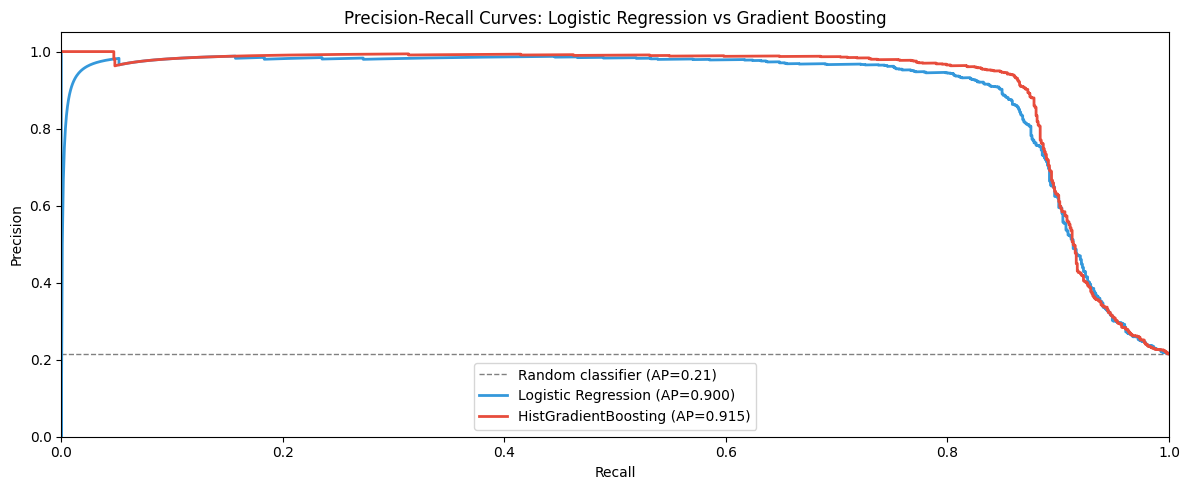

Figure: Precision-recall curves for both models vs a random classifier baseline. Gradient boosting outperforms logistic regression across most of the recall range, particularly at high-precision operating points relevant for automated enforcement. Note that even the boosting model has a precision ceiling imposed by label noise in the training data.


In [8]:
fig, ax = plt.subplots(figsize=FIGSIZE)

baseline_precision = y.mean()
ax.axhline(baseline_precision, color="gray", linestyle="--", linewidth=1, label=f"Random classifier (AP={baseline_precision:.2f})")

lr_prec, lr_rec, _ = precision_recall_curve(y, logit_proba)
ax.plot(lr_rec, lr_prec, color=COLOR_LOGIT, linewidth=2, label=f"Logistic Regression (AP={logit_ap:.3f})")

gbt_prec, gbt_rec, _ = precision_recall_curve(y, gbt_proba)
ax.plot(gbt_rec, gbt_prec, color=COLOR_GBT, linewidth=2, label=f"HistGradientBoosting (AP={gbt_ap:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves: Logistic Regression vs Gradient Boosting")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(loc="lower center")

plt.tight_layout()
plt.show()
print("Figure: Precision-recall curves for both models vs a random classifier baseline. Gradient boosting outperforms logistic regression across most of the recall range, particularly at high-precision operating points relevant for automated enforcement. Note that even the boosting model has a precision ceiling imposed by label noise in the training data.")

## 5. Operating Point Selection

Where should we set the score threshold for each action tier?

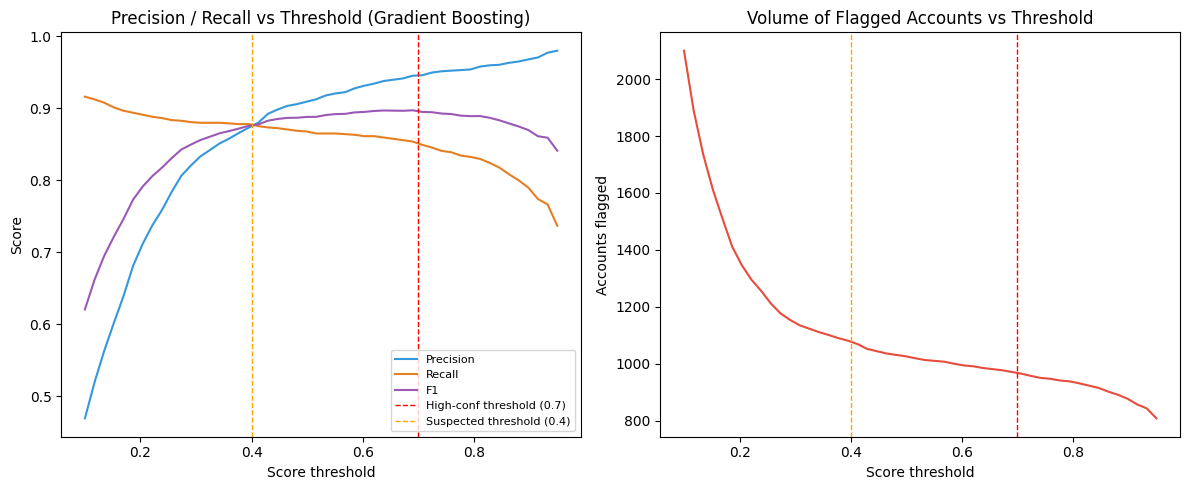

Figure: Threshold selection for the gradient boosting model. A threshold of 0.7 maps to 'high_confidence_abuse' (eligible for automated enforcement). A threshold of 0.4 maps to 'suspected' (flag for review). These thresholds should be calibrated against real-world label noise and enforcement capacity.


In [9]:
thresholds = np.linspace(0.1, 0.95, 50)
op_results = []
for t in thresholds:
    y_pred = (gbt_proba >= t).astype(int)
    p = precision_score(y, y_pred, zero_division=0)
    r = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    op_results.append({"threshold": t, "precision": p, "recall": r, "f1": f1, "flagged": int(y_pred.sum())})

op_df = pd.DataFrame(op_results)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

ax = axes[0]
ax.plot(op_df["threshold"], op_df["precision"], label="Precision", color="#3498db")
ax.plot(op_df["threshold"], op_df["recall"], label="Recall", color="#e67e22")
ax.plot(op_df["threshold"], op_df["f1"], label="F1", color="#9b59b6")
ax.axvline(0.7, color="red", linestyle="--", linewidth=1, label="High-conf threshold (0.7)")
ax.axvline(0.4, color="orange", linestyle="--", linewidth=1, label="Suspected threshold (0.4)")
ax.set_xlabel("Score threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall vs Threshold (Gradient Boosting)")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(op_df["threshold"], op_df["flagged"], color=COLOR_GBT)
ax.axvline(0.7, color="red", linestyle="--", linewidth=1)
ax.axvline(0.4, color="orange", linestyle="--", linewidth=1)
ax.set_xlabel("Score threshold")
ax.set_ylabel("Accounts flagged")
ax.set_title("Volume of Flagged Accounts vs Threshold")

plt.tight_layout()
plt.show()
print("Figure: Threshold selection for the gradient boosting model. A threshold of 0.7 maps to 'high_confidence_abuse' (eligible for automated enforcement). A threshold of 0.4 maps to 'suspected' (flag for review). These thresholds should be calibrated against real-world label noise and enforcement capacity.")

## 6. SHAP Explainability

In [10]:
# shap.Explainer auto-selects the best explainer for the model type
explainer = shap.Explainer(gbt_model, X)

# Sample 500 accounts for SHAP (full dataset can be slow)
sample_idx = np.random.default_rng(RANDOM_SEED).integers(0, len(X), 500)
X_sample = X.iloc[sample_idx]
# check_additivity=False: known compatibility quirk with HistGradientBoostingClassifier
shap_values = explainer(X_sample, check_additivity=False)

print(f"SHAP values computed for {len(X_sample)} sampled accounts.")

Background dataset has 5000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5000 when initializing the masker.


SHAP values computed for 500 sampled accounts.


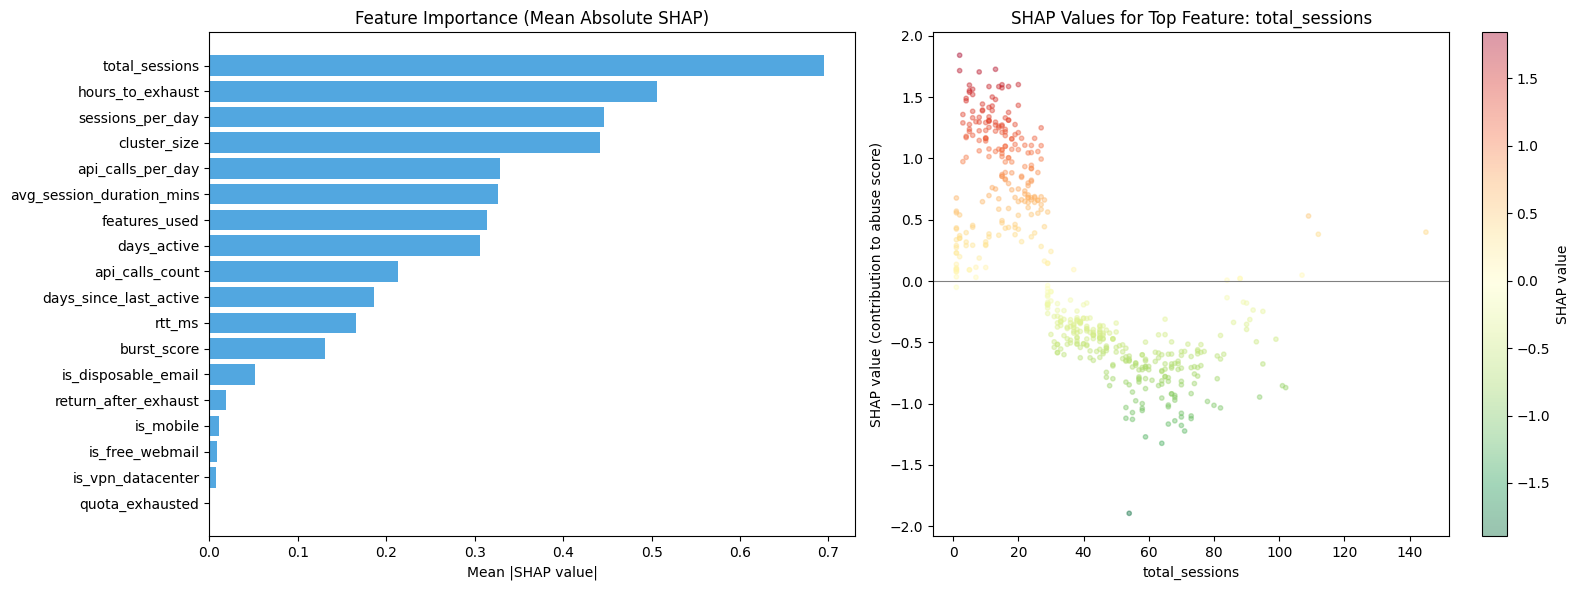

Figure: Left — mean absolute SHAP values rank features by their average contribution to the model's predictions. Right — SHAP scatter for the top feature shows how its value maps to model impact, revealing non-linear relationships that logistic regression cannot capture.


In [11]:
# Extract values array (shape: n_samples x n_features)
sv = shap_values.values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SHAP bar plot: mean absolute impact
ax = axes[0]
mean_abs_shap = pd.Series(
    np.abs(sv).mean(axis=0),
    index=X.columns,
).sort_values(ascending=True)

ax.barh(mean_abs_shap.index, mean_abs_shap.values, color="#3498db", alpha=0.85)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Feature Importance (Mean Absolute SHAP)")

# SHAP scatter: top feature vs SHAP value
ax = axes[1]
top_feature = mean_abs_shap.index[-1]
top_idx = list(X.columns).index(top_feature)
feature_vals = X_sample[top_feature].values
shap_top = sv[:, top_idx]
scatter = ax.scatter(feature_vals, shap_top, alpha=0.4, c=shap_top, cmap="RdYlGn_r", s=10)
plt.colorbar(scatter, ax=ax, label="SHAP value")
ax.set_xlabel(top_feature)
ax.set_ylabel("SHAP value (contribution to abuse score)")
ax.set_title(f"SHAP Values for Top Feature: {top_feature}")
ax.axhline(0, color="gray", linewidth=0.8)

plt.tight_layout()
plt.show()
print("Figure: Left — mean absolute SHAP values rank features by their average contribution to the model's predictions. Right — SHAP scatter for the top feature shows how its value maps to model impact, revealing non-linear relationships that logistic regression cannot capture.")

## 7. Model Limitations and Calibration Notes

**What the model does well:**
- Captures non-linear interactions (e.g., fast exhaustion + high cluster size is more predictive than either alone)
- Generalizes better than rules to accounts that evade individual heuristics
- Provides a continuous risk score usable for tiered enforcement

**What the model does not do:**
- It cannot exceed the accuracy of its training labels. If labels are ~85% accurate, model precision is bounded at ~85%, regardless of algorithm sophistication.
- SHAP explains what features drive predictions, not what drives actual abuse. These are the same only if the labels are accurate.
- The model was trained on simulated data with known parameters. Real-world performance will differ — calibrate against human-reviewed accounts before using for enforcement.

**Deployment recommendation:**
- Use model score >= 0.7 as input to `high_confidence_abuse` tier
- Use model score 0.4-0.7 as input to `suspected` tier
- Never use score < 0.4 for any enforcement action
- Retrain quarterly as user behavior and product features evolve